# 05. Общий обзор рынка ОФЗ

Ноутбук соответствует первой странице дашборда: общая динамика среднего процентного показателя ОФЗ, ключевой ставки, спреда и объёма торгов.

Используются только дневные данные из `data/processed/ofz_for_datalens_daily_2016_2026.csv`.


## 1. Импорт и загрузка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SUMMARY_DIR = DATA_DIR / "summary"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"

for path in [SUMMARY_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

In [2]:
DAILY_PATH = PROCESSED_DIR / "ofz_for_datalens_daily_2016_2026.csv"

if not DAILY_PATH.exists():
    raise FileNotFoundError(f"Файл не найден: {DAILY_PATH.resolve()}. Сначала запустите 04_prepare_datalens_datasets.ipynb")

df = pd.read_csv(DAILY_PATH)
df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"], errors="coerce")

print("Daily DataLens shape:", df.shape)
display(df.head())

Daily DataLens shape: (15522, 13)


,TRADEDATE,SECID,SHORTNAME,COUPON_TYPE,PLOT_GROUP,PRICE_FOR_ANALYSIS,YIELD_FOR_ANALYSIS,RATE_FOR_ANALYSIS,YEARS_TO_MATURITY,VALUE,key_rate,YIELD_KEY_RATE_SPREAD,RATE_KEY_RATE_SPREAD
0,2016-05-04,SU26207RMFS9,ОФЗ 26207,fixed,long,95.5773,8.99,8.99,10.751540,7.549269e+08,11.0,-2.01,-2.01
1,2016-05-05,SU26207RMFS9,ОФЗ 26207,fixed,long,95.6335,8.98,8.98,10.748802,1.133353e+08,11.0,-2.02,-2.02
2,2016-05-06,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7770,8.95,8.95,10.746064,2.091805e+08,11.0,-2.05,-2.05
3,2016-05-10,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7496,8.96,8.96,10.735113,2.660816e+07,11.0,-2.04,-2.04
4,2016-05-11,SU26207RMFS9,ОФЗ 26207,fixed,long,96.3739,8.86,8.86,10.732375,5.351472e+08,11.0,-2.14,-2.14


## 2. Дневная динамика среднего показателя, ставки и объёма торгов

In [3]:
market_daily = (
    df
    .groupby("TRADEDATE", as_index=False)
    .agg(
        avg_rate_for_analysis=("RATE_FOR_ANALYSIS", "mean"),
        median_rate_for_analysis=("RATE_FOR_ANALYSIS", "median"),
        total_value=("VALUE", "sum"),
        key_rate=("key_rate", "last"),
        n_bonds=("SECID", "nunique"),
    )
    .sort_values("TRADEDATE")
)

market_daily["avg_spread_to_key_rate"] = market_daily["avg_rate_for_analysis"] - market_daily["key_rate"]

display(market_daily.head())

,TRADEDATE,avg_rate_for_analysis,median_rate_for_analysis,total_value,key_rate,n_bonds,avg_spread_to_key_rate
0,2016-05-04,8.99,8.99,7.549269e+08,11.0,1,-2.01
1,2016-05-05,8.98,8.98,1.133353e+08,11.0,1,-2.02
2,2016-05-06,8.95,8.95,2.091805e+08,11.0,1,-2.05
3,2016-05-10,8.96,8.96,2.660816e+07,11.0,1,-2.04
4,2016-05-11,8.86,8.86,5.351472e+08,11.0,1,-2.14


## 3. График среднего процентного показателя и ключевой ставки

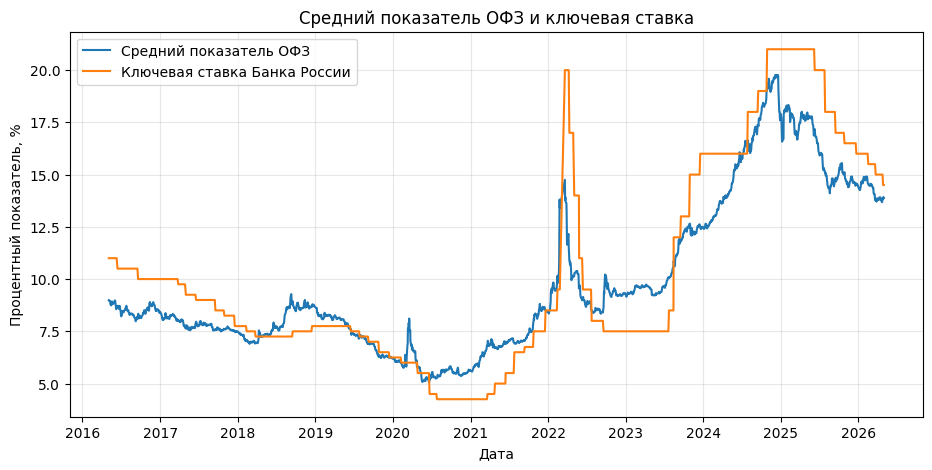

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_1_avg_rate_and_key_rate_daily.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(market_daily["TRADEDATE"], market_daily["avg_rate_for_analysis"], label="Средний показатель ОФЗ")
ax.plot(market_daily["TRADEDATE"], market_daily["key_rate"], label="Ключевая ставка Банка России")

ax.set_title("Средний показатель ОФЗ и ключевая ставка")
ax.set_xlabel("Дата")
ax.set_ylabel("Процентный показатель, %")
ax.grid(True, alpha=0.3)
ax.legend()

figure_path = FIGURES_DIR / "page_1_avg_rate_and_key_rate_daily.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())

## 4. График спреда к ключевой ставке

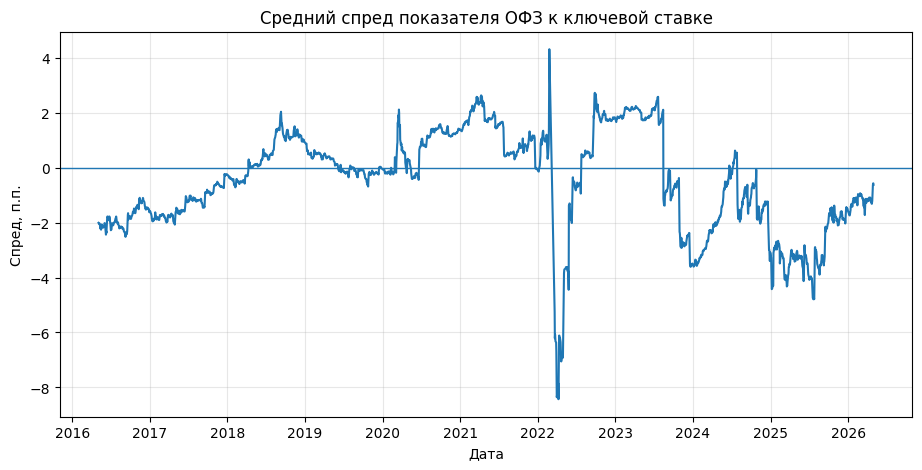

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_1_avg_spread_to_key_rate_daily.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(market_daily["TRADEDATE"], market_daily["avg_spread_to_key_rate"])
ax.axhline(0, linewidth=1)

ax.set_title("Средний спред показателя ОФЗ к ключевой ставке")
ax.set_xlabel("Дата")
ax.set_ylabel("Спред, п.п.")
ax.grid(True, alpha=0.3)

figure_path = FIGURES_DIR / "page_1_avg_spread_to_key_rate_daily.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())

## 5. График дневного объёма торгов

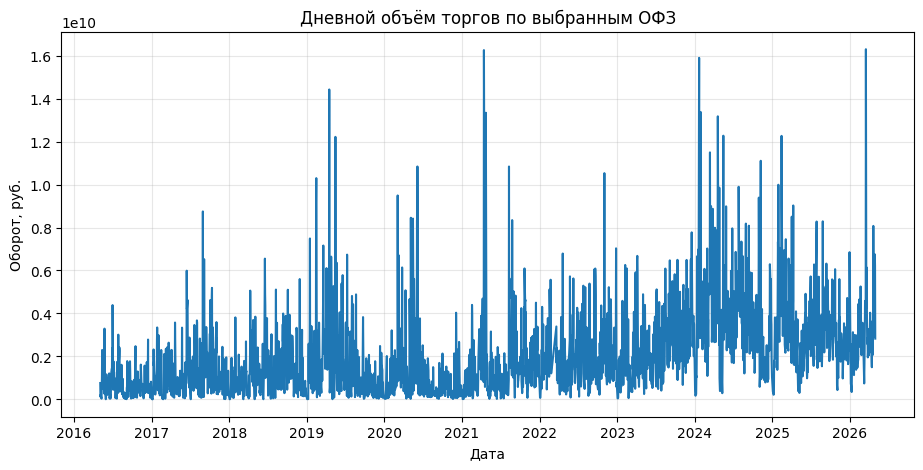

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_1_total_trading_value_daily.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(market_daily["TRADEDATE"], market_daily["total_value"])
ax.set_title("Дневной объём торгов по выбранным ОФЗ")
ax.set_xlabel("Дата")
ax.set_ylabel("Оборот, руб.")
ax.grid(True, alpha=0.3)

figure_path = FIGURES_DIR / "page_1_total_trading_value_daily.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())